# Apresentação para a operação — o B-8802B se atualiza sozinho (com a confirmação de vocês)

Este notebook gera as figuras da apresentação, na ordem dos slides. Cores fixas em todas: **vermelho = alerta**,
**cinza = sem o sistema**, **verde = faixa normal**, **azul = sensor**. O eixo de tempo é sempre o mesmo
(jan/2025 a ago/2026) quando o assunto é o B-8802B em produção.

Usa os modelos do replay (`notebooks/drift/replay_pipeline_B-8802B.ipynb`, 12 retreinos mensais rodados no ClearML).

In [1]:
import sys, json, shutil, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import monitor as mon

VERMELHO, CINZA, VERDE, AZUL = "tab:red", "darkgray", "green", "tab:blue"
R = PROJECT_ROOT / "results/replay_pipeline"     # python scripts/replay_pipeline.py --baixar 28fb7c95e4df46b38782472e1837f857 --out results/replay_pipeline
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
raw = si.carregar_dados(DADOS); FIM = raw.index.max(); INI = raw.index.min()
B_2022 = DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE"
B_ATUAL = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"

# o modelo de 2022 com as mesmas regras de alerta do sistema (alarme de 1 h ou mais), numa cópia
B_ANTIGO = R / "modelo_2022_regras_novas"
if not B_ANTIGO.exists(): shutil.copytree(B_2022, B_ANTIGO)
a = json.loads((B_ANTIGO / "alarm.json").read_text())
a.update({"debounce_window": 20, "debounce_min": 15, "persistence_mode": "time", "persistence_step": "5min", "min_alert_hours": 1.0})
(B_ANTIGO / "alarm.json").write_text(json.dumps(a, indent=1, ensure_ascii=False))

def alerta(bundle, ini, fim):
    seg = raw.loc[ini - pd.Timedelta(days=1): fim]
    r = si.prever(bundle, si.carregar_modelo(bundle), si.preprocessar(bundle, seg), df_bruto=seg)["alerta"]
    return r[(r.index >= ini) & (r.index < fim)]

def blocos(flag):
    a = flag[flag]
    if a.empty: return []
    return [(e.index.min(), e.index.max()) for _, e in a.groupby((a.index.to_series().diff() > pd.Timedelta("1h")).cumsum())]

resumo = pd.read_csv(R / "resumo.csv")
agenda = [(B_ANTIGO, INI)] + [(PROJECT_ROOT / r.bundle, pd.Timestamp(r.treino_fim)) for r in resumo.itertuples() if r.aprovado]
sistema = pd.concat([alerta(b, ini, agenda[i + 1][1] if i + 1 < len(agenda) else FIM) for i, (b, ini) in enumerate(agenda)])
antigo = alerta(B_ANTIGO, INI, FIM)
T_AVISO = mon.ks_daily_fires(DADOS, B_2022)[0][0]
T_RETREINO, T_12 = agenda[1][1], agenda[-1][1]
op = raw[raw["Pressão Descarga"] > 35]
print(f"modelo antigo mantido: {len(blocos(antigo))} alertas, {100 * antigo.mean():.0f} % do tempo | "
      f"sistema depois do 1º retreino: {len(blocos(sistema[sistema.index >= T_RETREINO]))} alertas")

modelo antigo mantido: 269 alertas, 12 % do tempo | sistema depois do 1º retreino: 2 alertas


## Slide 1 — Depois do reparo, o modelo antigo virou um alarme que ninguém ouve

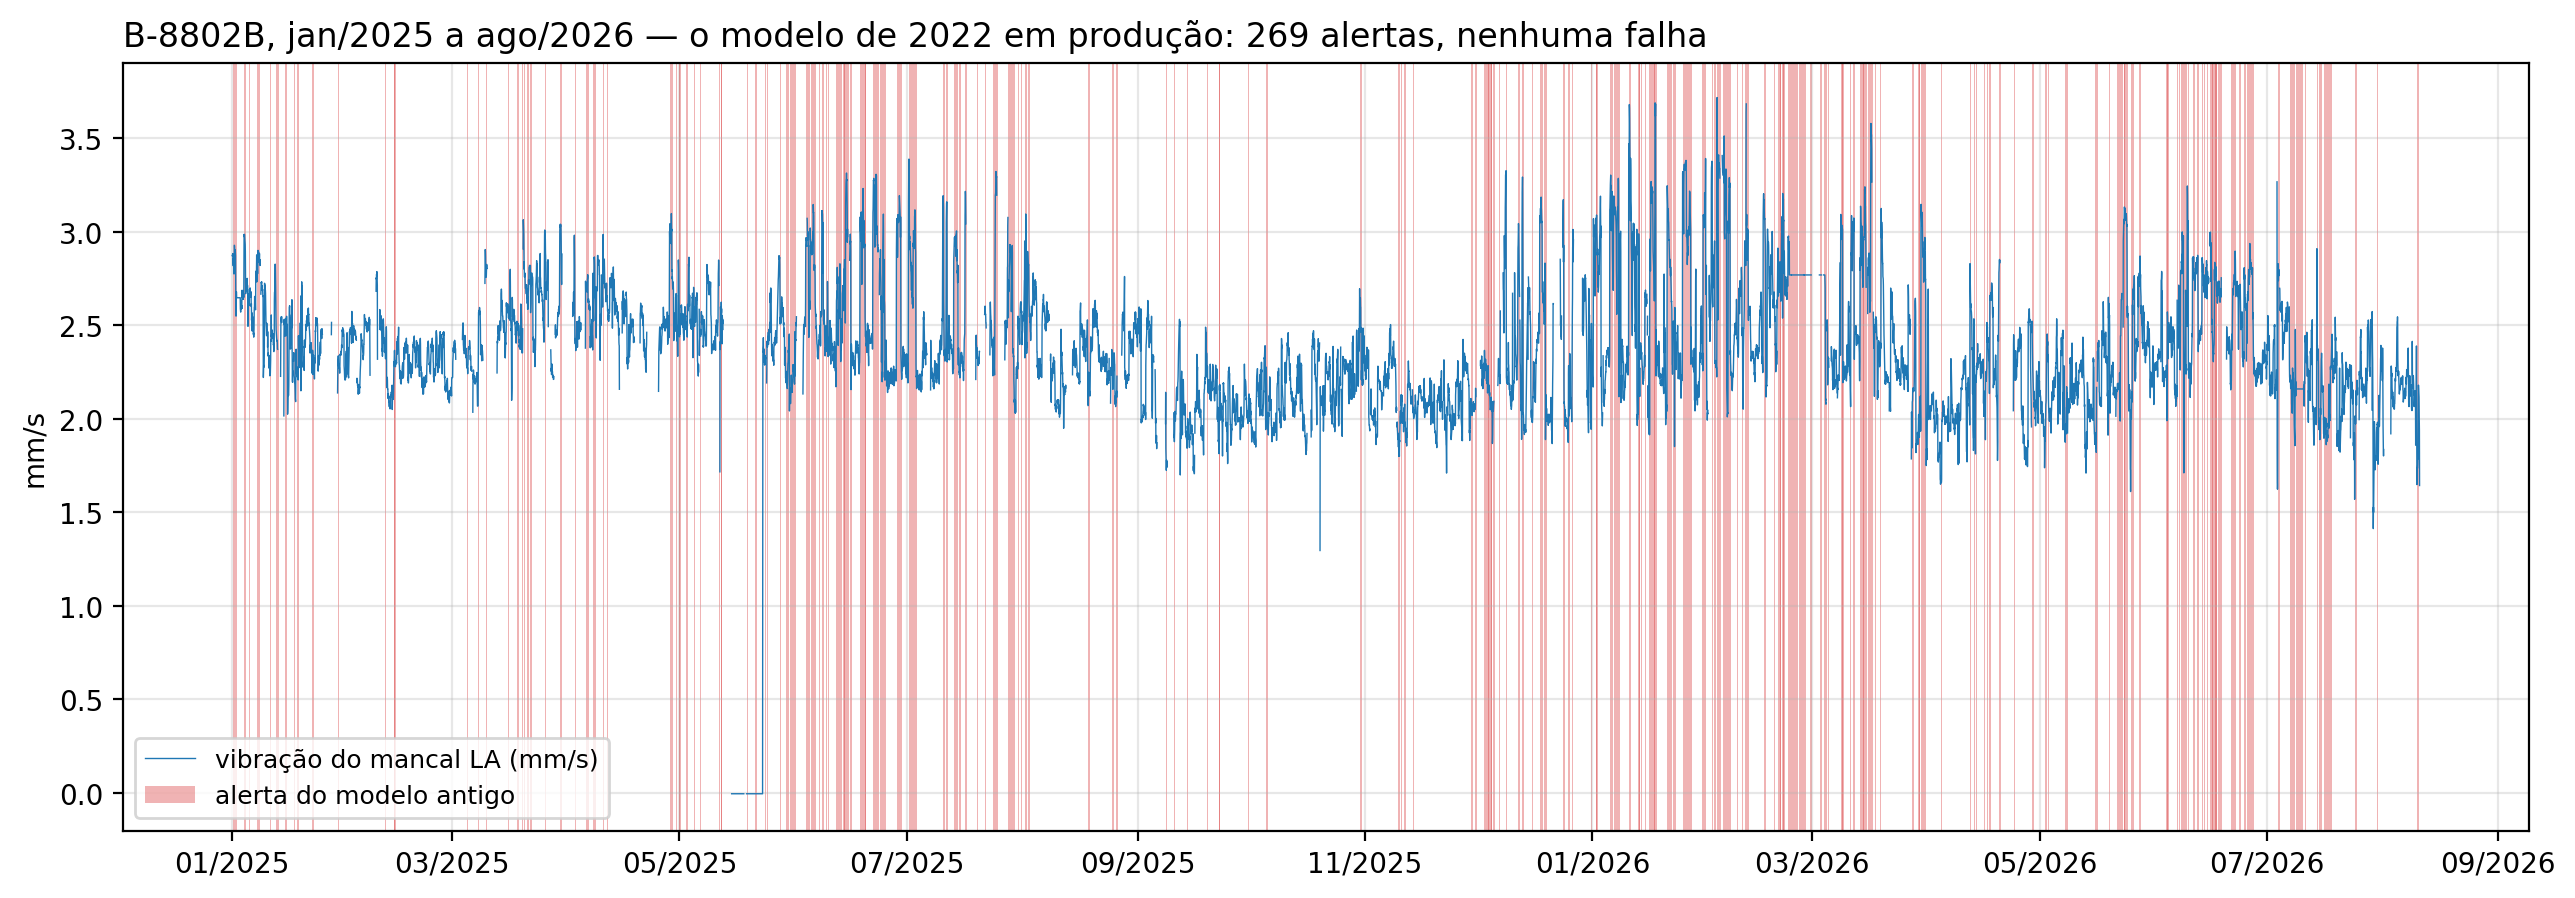

In [2]:
h = op["Vibração Bomba LA"].resample("1h").mean()
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(h.index, h, linewidth=0.5, color=AZUL, label="vibração do mancal LA (mm/s)")
for n, (a, b) in enumerate(blocos(antigo)):
    ax.axvspan(a, b + pd.Timedelta(hours=6), color=VERMELHO, alpha=0.35, linewidth=0, label="alerta do modelo antigo" if n == 0 else None)
ax.set_ylabel("mm/s"); ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=9)
ax.set_title(f"B-8802B, jan/2025 a ago/2026 — o modelo de 2022 em produção: {len(blocos(antigo))} alertas, nenhuma falha", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

## Slide 2 — Falha e "normal novo" são coisas diferentes

À esquerda, a falha de 2022 do B-8802B: a vibração sobe e a bomba quebra em 2 dias. À direita, o normal novo do
B-4064A depois do reparo de 2024: a temperatura do mancal LNA muda de patamar e fica (a operação confirmou).

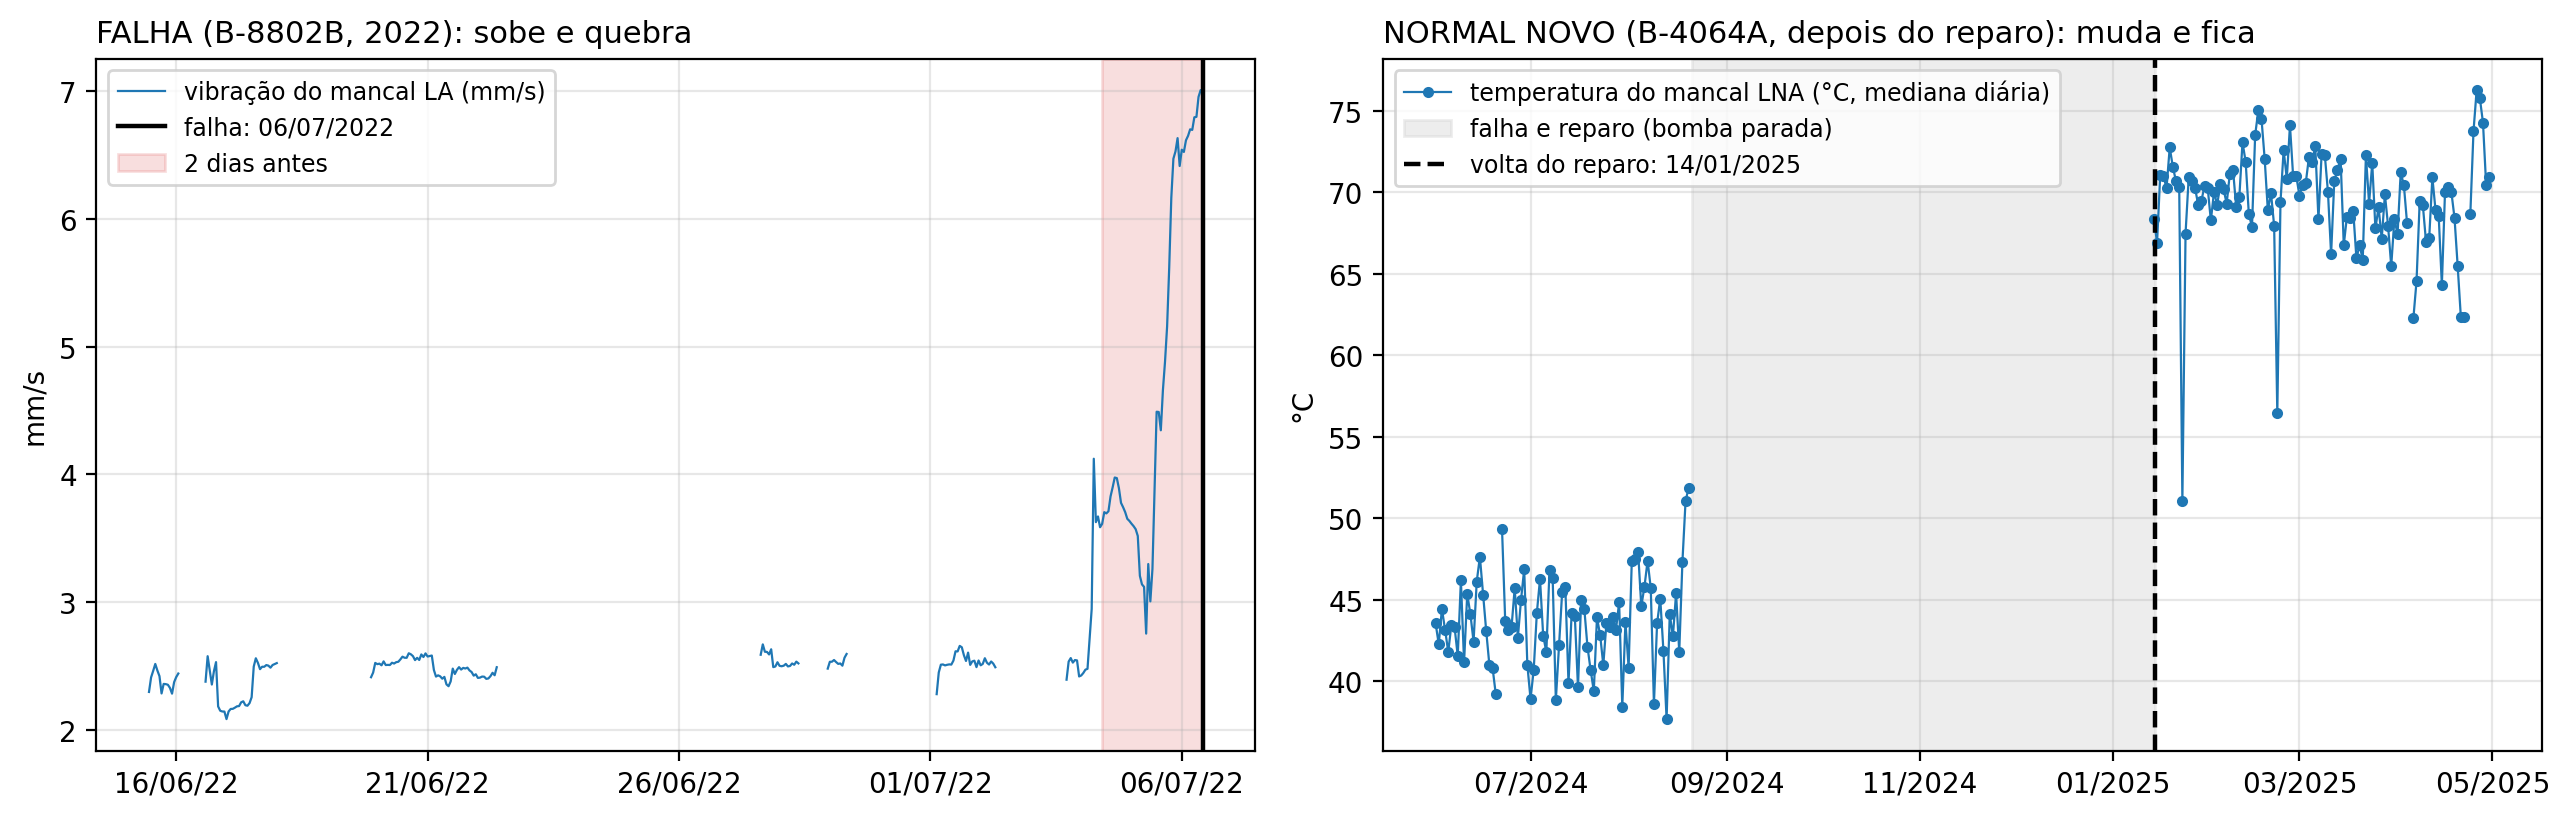

In [3]:
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
raw22 = si.carregar_dados(next((DEP / "B-8802B/dados").rglob("*_raw.csv")))
op22 = raw22[raw22["Pressão Descarga"] > 35]
raw4 = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-4064A_novos.feather")
if "Timestamp" in raw4.columns: raw4 = raw4.set_index("Timestamp"); raw4.index = pd.to_datetime(raw4.index)
s4, _, _ = run_preprocessing(raw4.sort_index(), EQUIPMENT_CONFIGS["B-4064A-prod"].pre_split_steps)
FALHA22, VOLTA4 = pd.Timestamp("2022-07-06 10:00"), pd.Timestamp("2025-01-14 12:00")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
v = op22["Vibração Bomba LA"].loc["2022-06-15":FALHA22].resample("1h").mean()
axes[0].plot(v.index, v, linewidth=0.8, color=AZUL, label="vibração do mancal LA (mm/s)")
axes[0].axvline(FALHA22, color="black", linewidth=1.6, label="falha: 06/07/2022")
axes[0].axvspan(FALHA22 - pd.Timedelta(days=2), FALHA22, color=VERMELHO, alpha=0.15, label="2 dias antes")
axes[0].set_title("FALHA (B-8802B, 2022): sobe e quebra", loc="left", fontsize=11)
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=5)); axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y")); axes[0].set_ylabel("mm/s")
t = s4["Temperatura Bomba LNA"].resample("1D").median()
t = pd.concat([t.loc["2024-06-01":"2024-08-20"], t.loc[VOLTA4.normalize():"2025-04-30"]]).asfreq("1D")   # sem a rampa da falha de ago/2024
axes[1].plot(t.index, t, marker=".", linewidth=0.8, color=AZUL, label="temperatura do mancal LNA (°C, mediana diária)")
axes[1].axvspan(pd.Timestamp("2024-08-21"), VOLTA4, color="lightgray", alpha=0.4, label="falha e reparo (bomba parada)")
axes[1].axvline(VOLTA4, color="black", linewidth=1.6, linestyle="--", label="volta do reparo: 14/01/2025")
axes[1].set_title("NORMAL NOVO (B-4064A, depois do reparo): muda e fica", loc="left", fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); axes[1].set_ylabel("°C")
for ax in axes: ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

## Slide 4 — Resultado: de 269 alertas falsos para 2

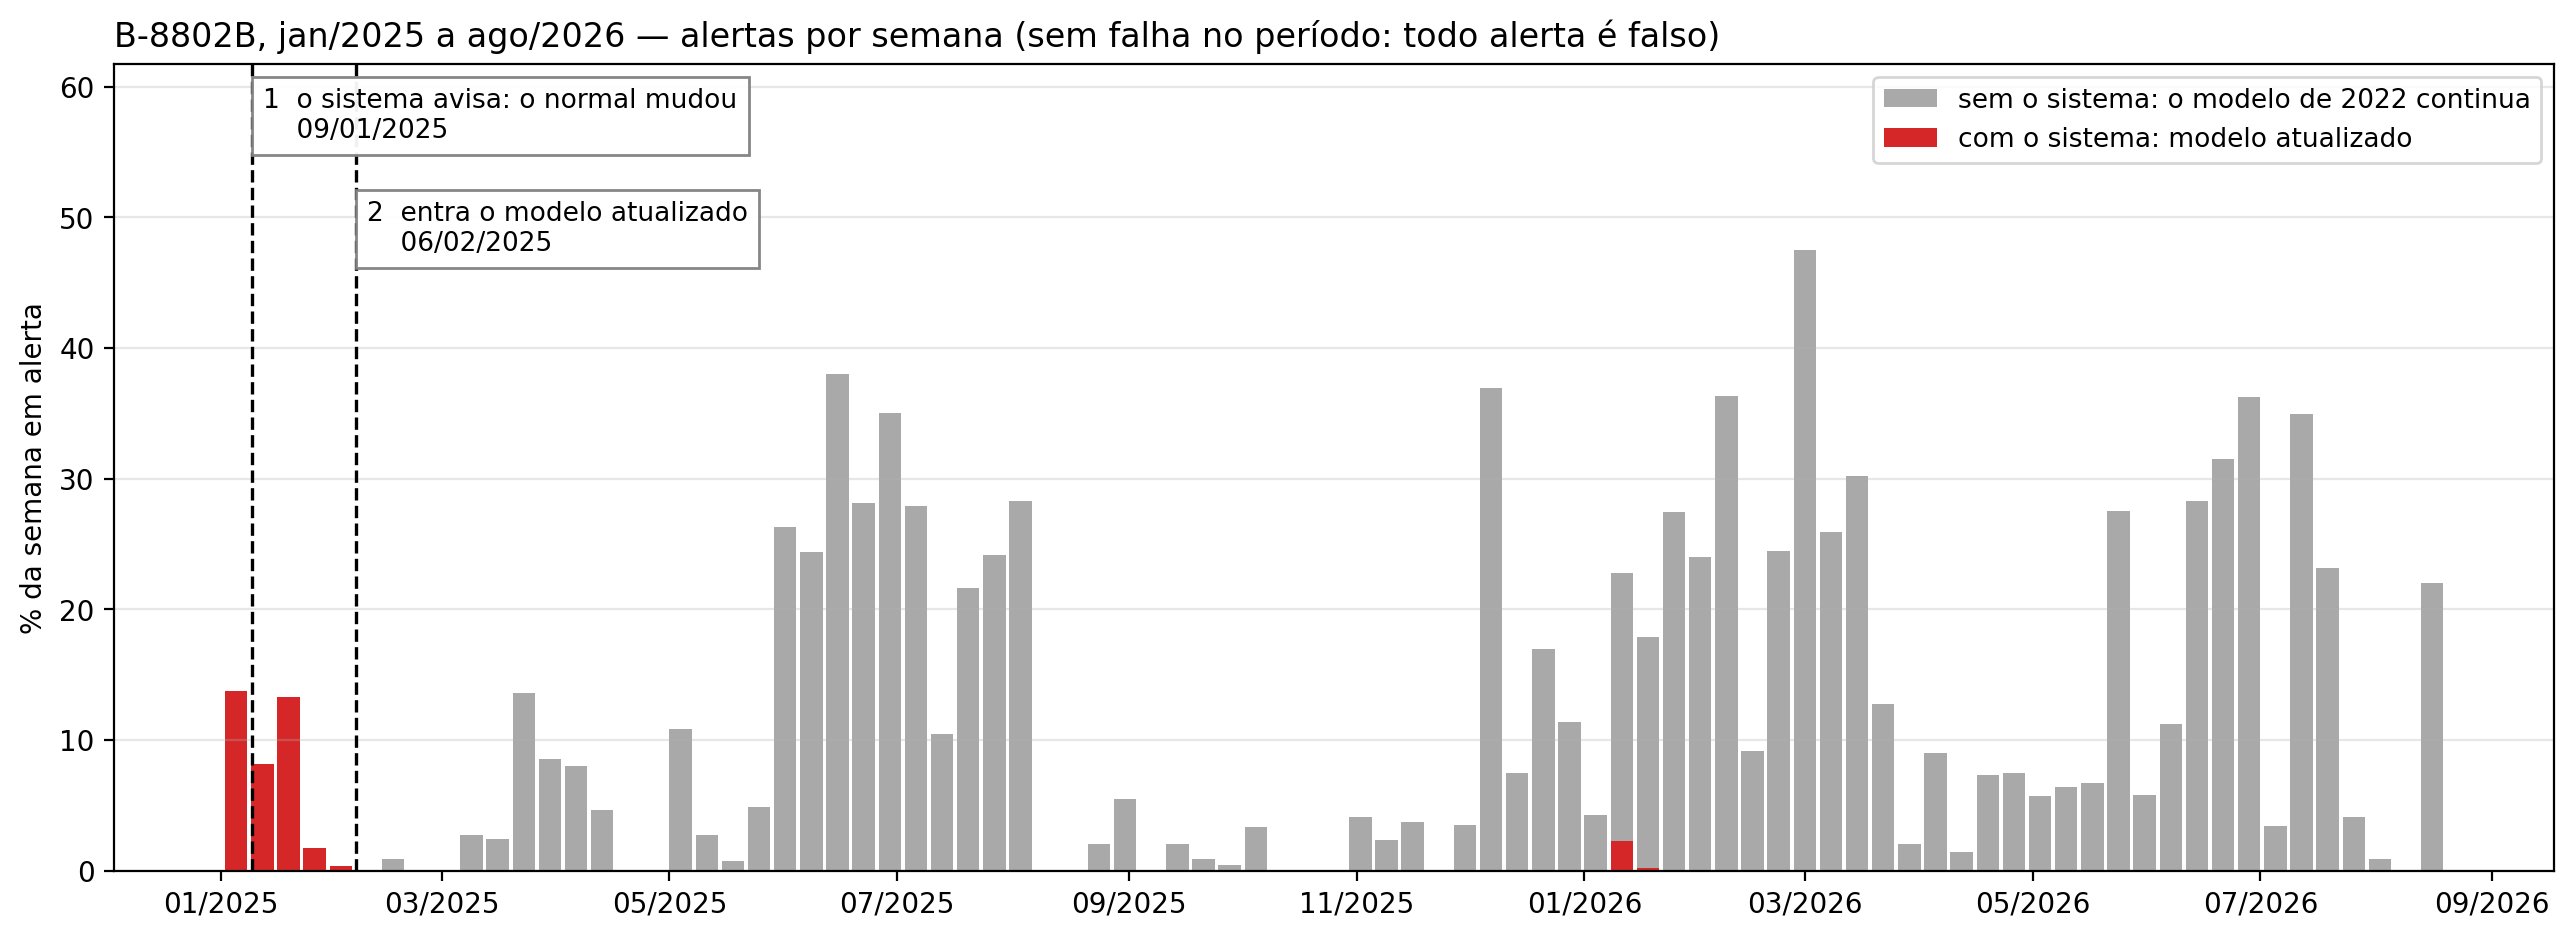

In [4]:
sem = lambda r: 100 * r.groupby(pd.Grouper(freq="W")).mean()
s_ant, s_sis = sem(antigo), sem(sistema)
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(s_ant.index, s_ant.values, width=6, color=CINZA, label="sem o sistema: o modelo de 2022 continua")
ax.bar(s_sis.index, s_sis.values, width=6, color=VERMELHO, label="com o sistema: modelo atualizado")
topo = s_ant.max() * 1.3; ax.set_ylim(0, topo)
for t, n, txt, y in [(T_AVISO, "1", "o sistema avisa: o normal mudou", 0.97), (T_RETREINO, "2", "entra o modelo atualizado", 0.83)]:
    ax.axvline(t, color="black", linewidth=1.2, linestyle="--")
    ax.text(t + pd.Timedelta(days=3), topo * y, f"{n}  {txt}\n    {t:%d/%m/%Y}", va="top", fontsize=9.5,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.95))
ax.set_ylabel("% da semana em alerta"); ax.grid(alpha=0.3, axis="y"); ax.legend(loc="upper right", fontsize=9.5)
ax.set_title("B-8802B, jan/2025 a ago/2026 — alertas por semana (sem falha no período: todo alerta é falso)", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

## Slide 5 — E continua pegando falha

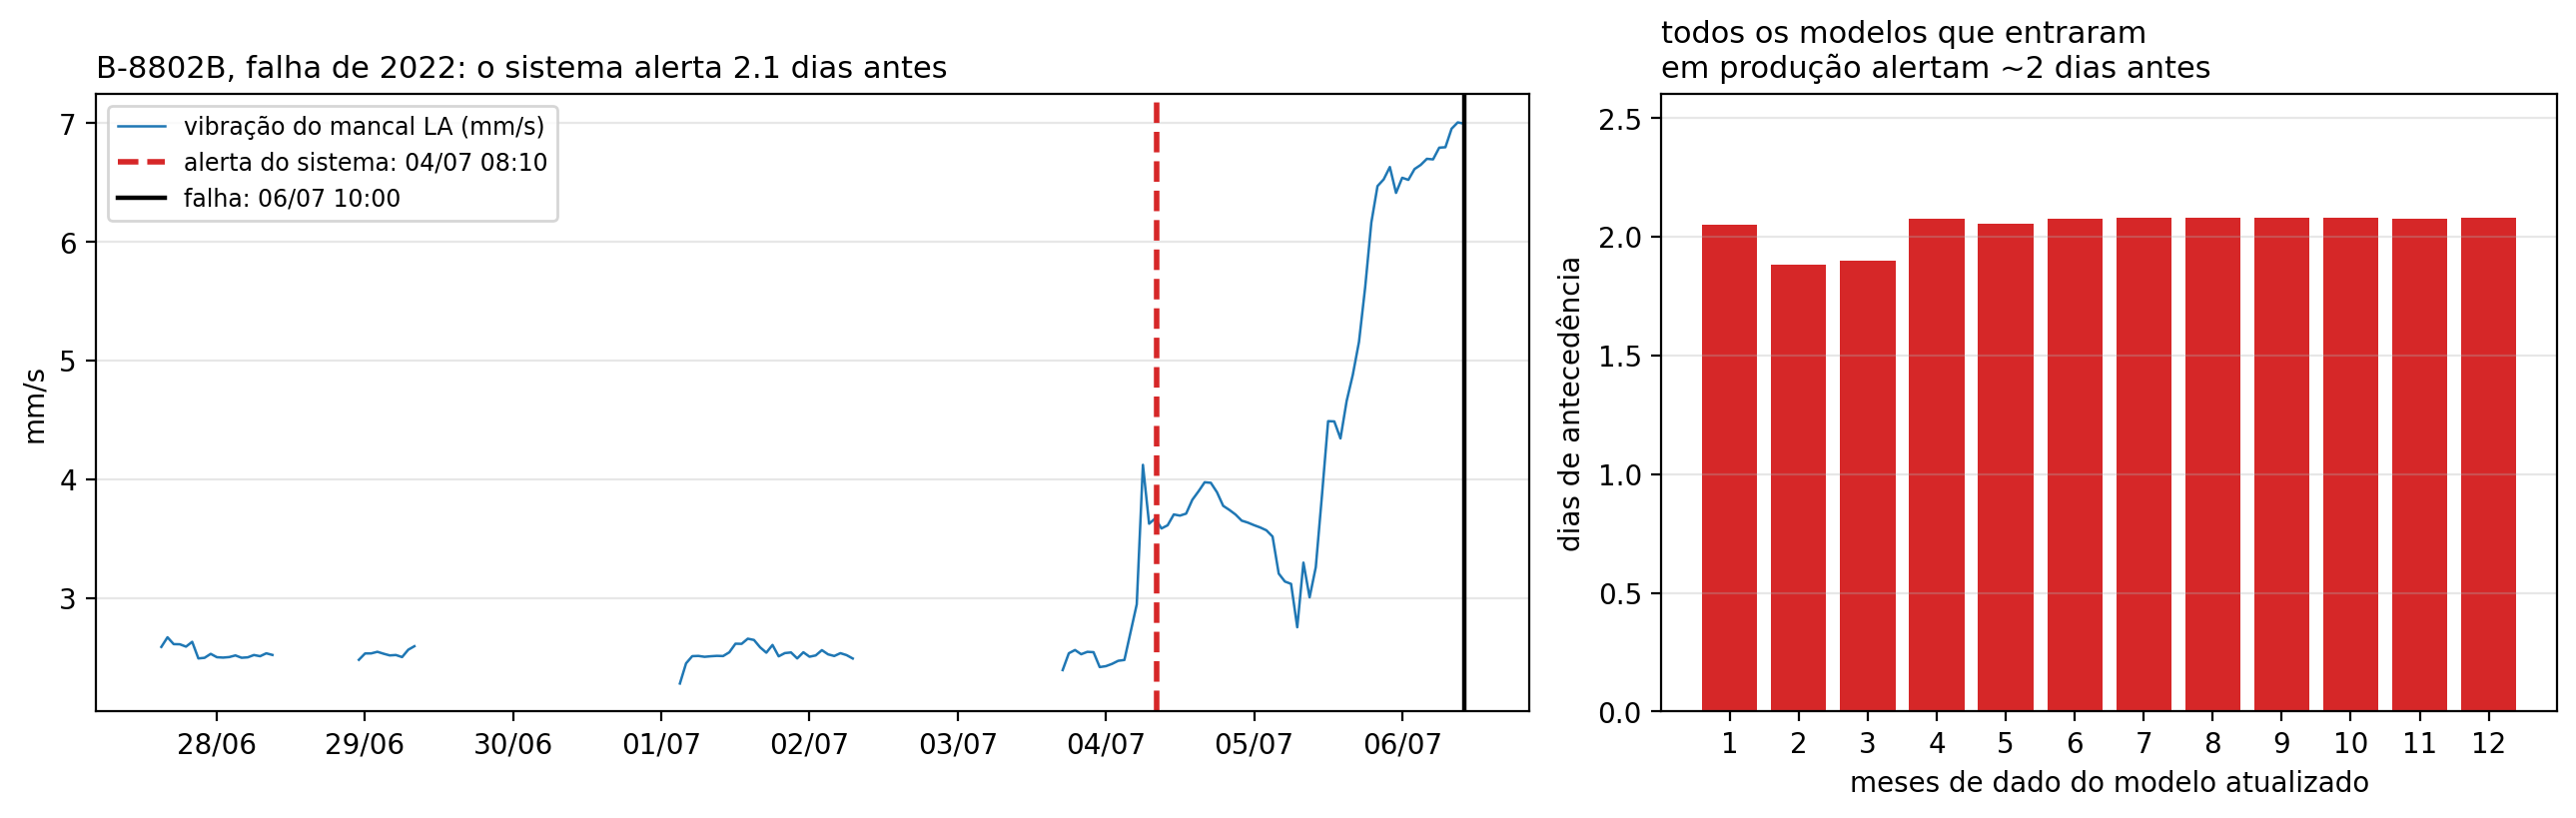

In [5]:
al22 = si.prever(B_ATUAL, si.carregar_modelo(B_ATUAL), si.preprocessar(B_ATUAL, raw22), df_bruto=raw22)["alerta"]
t_al = al22[(al22.index >= "2022-06-29") & al22].index.min()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
v = op22["Vibração Bomba LA"].loc["2022-06-25":FALHA22].resample("1h").mean()
axes[0].plot(v.index, v, linewidth=0.9, color=AZUL, label="vibração do mancal LA (mm/s)")
axes[0].axvline(t_al, color=VERMELHO, linewidth=2, linestyle="--", label=f"alerta do sistema: {t_al:%d/%m %H:%M}")
axes[0].axvline(FALHA22, color="black", linewidth=1.6, label="falha: 06/07 10:00")
axes[0].set_title(f"B-8802B, falha de 2022: o sistema alerta {(FALHA22 - t_al).total_seconds() / 86400:.1f} dias antes", loc="left", fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); axes[0].set_ylabel("mm/s"); axes[0].legend(loc="upper left", fontsize=8.5)
axes[1].bar(resumo["etapa"], resumo["falha_2022_dias"], color=VERMELHO)
axes[1].set_ylim(0, 2.6); axes[1].set_xticks(resumo["etapa"])
axes[1].set_xlabel("meses de dado do modelo atualizado"); axes[1].set_ylabel("dias de antecedência")
axes[1].set_title("todos os modelos que entraram\nem produção alertam ~2 dias antes", loc="left", fontsize=11)
for ax in axes: ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Slide 6 — O sistema também pegou uma mudança nova, em 2026

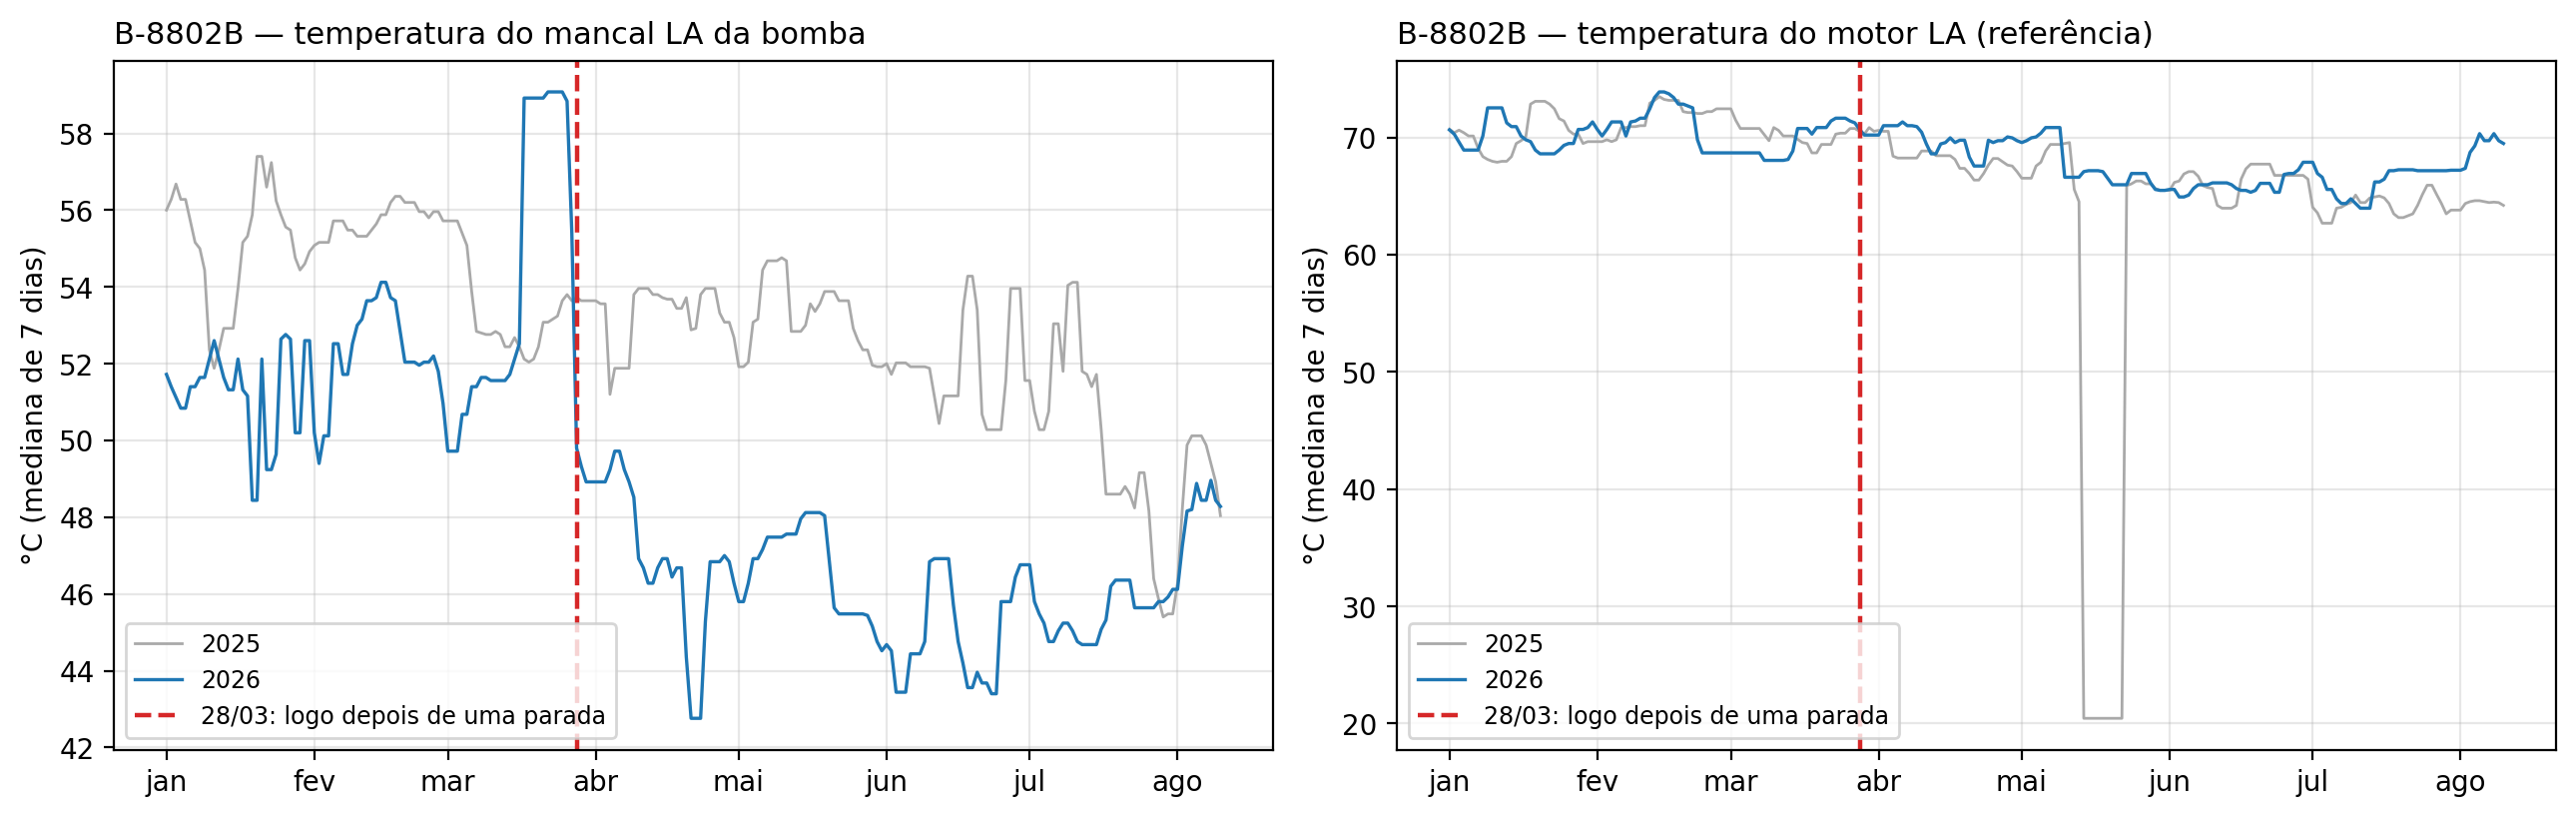

mancal LA, 2026 − 2025 por mês (°C): {1: -4.1, 2: -3.3, 3: -1.1, 4: -6.1, 5: -6.8, 6: -7.6, 7: -4.4, 8: -1.3}


In [6]:
d = op[["Temperatura Bomba LA", "Temperatura Motor LA"]].resample("1D").median()
d["dia"] = d.index.dayofyear
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
for ax, c, nome in zip(axes, ["Temperatura Bomba LA", "Temperatura Motor LA"], ["mancal LA da bomba", "motor LA (referência)"]):
    for ano, cor, lw in [(2025, CINZA, 1.0), (2026, AZUL, 1.2)]:
        s = d[d.index.year == ano].loc[lambda x: x["dia"] <= 222]
        ax.plot(s["dia"], s[c].rolling(7, min_periods=3, center=True).median(), color=cor, linewidth=lw, label=str(ano))
    ax.axvline(pd.Timestamp("2026-03-28").dayofyear, color=VERMELHO, linewidth=1.6, linestyle="--", label="28/03: logo depois de uma parada")
    ax.set_title(f"B-8802B — temperatura do {nome}", loc="left", fontsize=11); ax.set_ylabel("°C (mediana de 7 dias)")
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213]); ax.set_xticklabels(["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago"])
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8.5)
plt.tight_layout(); plt.show()
m = op.groupby([op.index.year, op.index.month])["Temperatura Bomba LA"].median()
print("mancal LA, 2026 − 2025 por mês (°C):", (m.loc[2026] - m.loc[2025].loc[m.loc[2026].index]).round(1).to_dict())